# Bachelor Thesis

© 2026 Yvan Richard   
University of St. Gallen, Spring Term 2026

## Exploring Hypothesis 1

---
## Foreword

In this notebook, my goal is to explore this hypothesis:

$$
\mathbb{E}[\Delta\textit{users\_close}_{i, t + 1} \mid \text{high}(ASVI_{i, t})] \ge 0
$$

where $ASVI_{i, t}$ translates abnormal volume in Google Trends. In other words, the purpose of this hypothesis is to explore whether lagged attention spikes in Google Trends can predict an increase in the number of Robinhood users holding a stock $i$ at time $t+1$. Additionally, I will also focus on the following question: "Among competing attention proxies, which ones contain incremental information about next-day retail demand on Robinhood?"


## 1. Libraries & Data

I first load the relevant libraries and data.

In [29]:
# libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from linearmodels import OLS
from linearmodels.panel import PanelOLS

In [30]:
# data
main = pd.read_csv("../../../data/processed/herding_events_full_attention.csv")

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_80032/2645465387.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  main = pd.read_csv("../../../data/processed/herding_events_full_attention.csv")


Once I loaded the data, I parse the date accordingly.

In [31]:
# date format
main["date"] = pd.to_datetime(main["date"])

## 2. Exploratory Data Analysis

In this section, I conduct a brief EDA.

In [32]:
# the columns
main.columns

Index(['date', 'users_close', 'users_start', 'users_last', 'intraday_userchg',
       'ticker', 'permno', 'ret', 'prc', 'vol', 'shrout', 'exchcd', 'symro',
       'symsu', 'buy_num_trades_LR', 'sell_num_trades_LR', 'total_trade_LR',
       'buy_vol_LR', 'sell_vol_LR', 'close_price', 'open_price', 'close_vol',
       'open_vol', 'total_vol_m', 'total_n_trades_m', 'intra_ret',
       'buy_num_trades_tick', 'sell_num_trades_tick', 'buy_vol_tick',
       'sell_vol_tick', 'total_trade_tick', 'buy_num_trades_wrds',
       'sell_num_trades_wrds', 'buy_vol_wrds', 'sell_vol_wrds',
       'total_trade_wrds', 'bs_ratio_num', 'bs_ratio_vol',
       'buy_num_trades_retail', 'sell_num_trades_retail', 'buy_vol_retail',
       'sell_vol_retail', 'total_trade_retail', 'total_vol_retail',
       'bs_ratio_retail_vol', 'bs_ratio_retail_num', 'intra_volatility',
       'buy_num_trades_inst50k', 'sell_num_trades_inst50k', 'buy_vol_inst50k',
       'sell_vol_inst50k', 'total_trade_inst50k', 'total_vol_inst5

In [33]:
# number of non-nan rows with svi and number of unique tickers in those rows
print(f"Number of non-nan rows with svi: {main['svi'].notna().sum()}")
print(f"Number of unique tickers in those rows: {main[main['date'].notna() & main['svi'].notna()]['ticker'].nunique()}")

Number of non-nan rows with svi: 1029430
Number of unique tickers in those rows: 1979


In [34]:
# shape, number of unique tickers
print(f"Shape of the dataset: {main.shape}")
print(f"Number of unique tickers: {main['ticker'].nunique()}")

Shape of the dataset: (1064799, 80)
Number of unique tickers: 1979


In [35]:
# number of unique tickers with non-nan ess, css, and anl_chg
print(f"Number of unique tickers with non-nan ess: {main[main['ess'].notna()]['ticker'].nunique()}")
print(f"Number of unique tickers with non-nan css: {main[main['css'].notna()]['ticker'].nunique()}")
print(f"Number of unique tickers with non-nan anl_chg: {main[main['anl_chg'].notna()]['ticker'].nunique()}")

Number of unique tickers with non-nan ess: 1572
Number of unique tickers with non-nan css: 1583
Number of unique tickers with non-nan anl_chg: 1583


## 3. Regressions

### 3.1. Basline Regression (Abnormal Volume and Returns)

The first regression is specifed as follows.

**Dependent Variable**

$$
\Delta \textit{users\_close}_{i, t} = {\textit{users\_close}_{i, t} - \textit{users\_close}_{i, t -1}}
$$

In [36]:
# select only relevant variables
df_reg_1 = main[['date', 'ticker', 'users_close', 'userchg', 'intraday_userchg', 'net_buys', 'ret', 'vol',
                 'svi', 'num_news', 'ess', 'css', 'anl_chg', 'num_news_relevant', 'asvi']].copy()

# replace nan values in num_news, num_news_relevant, ess, css, and anl_chg with 0 (assuming no news and no analyst changes if missing)
df_reg_1.fillna({'num_news': 0, 'num_news_relevant': 0, 'ess': 0, 'css': 0, 'anl_chg': 0}, inplace=True)

# sort by ticker and date
df_reg_1.sort_values(by=['ticker', 'date'], inplace=True)

# drop rows with missing raw inputs
# df_reg_1.dropna(subset=['users_close', 'userchg', 'ret', 'vol'], inplace=True)

# ln userchg
df_reg_1['ln_userchg'] = np.log(1 + np.abs(df_reg_1['userchg']))

# ab_ret_lag1
def make_ab_ret(s):
    lags = pd.concat([s.shift(k) for k in range(2, 22)], axis=1)
    mu = lags.mean(axis=1)
    sigma = lags.std(axis=1)
    z = (s.shift(1) - mu) / sigma
    z[sigma == 0] = np.nan
    return z

df_reg_1["ab_ret_lag1"] = df_reg_1.groupby("ticker")["ret"].transform(make_ab_ret)

# ret(t - 1)
df_reg_1['ret_lag1'] = df_reg_1.groupby('ticker')['ret'].shift(1)

# binary indicator for ret(t - 1) in the top 20 of the absolute returns. 
# if ret(t - 1) is in the top 20 of the absolute returns, then ab_ret_lag1 is 1, otherwise 0.
df_reg_1['top_20'] = (df_reg_1['ret_lag1'].abs() >= df_reg_1.groupby('ticker')['ret'].transform(lambda x: x.abs().nlargest(20).min())).astype(int)

# ab_vol_lag1
def make_ab_vol(s):
    lags = pd.concat([s.shift(k) for k in range(2, 22)], axis=1)
    mu = lags.mean(axis=1)
    ratio = s.shift(1) / mu
    ratio[mu == 0] = np.nan
    return np.log1p(np.abs(ratio))

df_reg_1["ab_vol_lag1"] = df_reg_1.groupby("ticker")["vol"].transform(make_ab_vol)

# lagged ess, css, and anl_chg
df_reg_1['ess_lag1'] = df_reg_1.groupby('ticker')['ess'].shift(1)
df_reg_1['css_lag1'] = df_reg_1.groupby('ticker')['css'].shift(1)
df_reg_1['anl_chg_lag1'] = df_reg_1.groupby('ticker')['anl_chg'].shift(1)

# lagged net_buys
df_reg_1['net_buys_lag1'] = df_reg_1.groupby('ticker')['net_buys'].shift(1)

# optional cleanup
# df_reg_1.replace([np.inf, -np.inf], np.nan, inplace=True)

# reg data
df_reg_1['userchg_lag1'] = df_reg_1.groupby('ticker')['userchg'].shift(1)

# lagged news and sentiment data
df_reg_1['num_news_lag1'] = df_reg_1.groupby('ticker')['num_news'].shift(1)
df_reg_1['num_news_relevant_lag1'] = df_reg_1.groupby('ticker')['num_news_relevant'].shift(1)
df_reg_1['ess_lag1'] = df_reg_1.groupby('ticker')['ess'].shift(1)
df_reg_1['css_lag1'] = df_reg_1.groupby('ticker')['css'].shift(1)
df_reg_1['anl_chg_lag1'] = df_reg_1.groupby('ticker')['anl_chg'].shift(1)

# dimensions and head
print(f"Shape of the regression dataset: {df_reg_1.shape}")

Shape of the regression dataset: (1064799, 27)


In [37]:
# reg data
reg1 = df_reg_1.copy().dropna(subset=[
    'userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1',
    'css_lag1', 'anl_chg_lag1'
])

# make sure date is datetime
reg1['date'] = pd.to_datetime(reg1['date'])

# convert clusters to integer codes
reg1['ticker_clust'] = reg1['ticker'].astype('category').cat.codes
reg1['date_clust'] = reg1['date'].astype('category').cat.codes

X1 = sm.add_constant(reg1[['top_20', 'ab_vol_lag1', 'asvi']])
y1 = reg1['userchg']

results1 = OLS(y1, X1).fit(
    cov_type='clustered',
    clusters=reg1[['ticker_clust', 'date_clust']]
)

print(results1.summary)

                            OLS Estimation Summary                            
Dep. Variable:                userchg   R-squared:                      0.0064
Estimator:                        OLS   Adj. R-squared:                 0.0064
No. Observations:              934966   F-statistic:                    50.471
Date:                Sat, Apr 04 2026   P-value (F-stat)                0.0000
Time:                        14:05:51   Distribution:                  chi2(3)
Cov. Estimator:             clustered                                         
                                                                              
                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
const          -19.778     5.0307    -3.9315     0.0001     -29.638     -9.9182
top_20          110.06     16.526     6.6594    

With fixed stocks and dates effect:

In [38]:
# reg data
reg1_a = df_reg_1.copy().dropna(subset=[
    'userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1',
    'css_lag1', 'anl_chg_lag1'
])

# make sure date is datetime
reg1_a['date'] = pd.to_datetime(reg1_a['date'])

# set panel index: entity = ticker, time = date
reg1_a = reg1_a.set_index(['ticker', 'date']).sort_index()

# dependent variable
y1 = reg1_a['userchg']

# regressors: do NOT add a constant when using both entity and time fixed effects
X1 = reg1_a[[
    'top_20', 'ab_vol_lag1', 'asvi'
]]

# fit the model with entity and time fixed effects
model1 = PanelOLS(y1, X1, entity_effects=True, time_effects=True)
results1_fe = model1.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print(results1_fe.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_80032/1940044841.py:24: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results1_fe = model1.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                userchg   R-squared:                        0.0032
Estimator:                   PanelOLS   R-squared (Between):             -0.0415
No. Observations:              934966   R-squared (Within):               0.0055
Date:                Sat, Apr 04 2026   R-squared (Overall):              0.0036
Time:                        14:05:54   Log-likelihood                -6.753e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      982.53
Entities:                        1958   P-value                           0.0000
Avg Obs:                       477.51   Distribution:                F(3,932475)
Min Obs:                       1.0000                                           
Max Obs:                       531.00   F-statistic (robust):             14.274
                            

### 3.2. Control for Persistence

In [39]:
reg2 = df_reg_1.copy().dropna(subset=[
    'userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1',
    'css_lag1', 'anl_chg_lag1'
])

# make sure date is datetime
reg2['date'] = pd.to_datetime(reg2['date'])

# convert clusters to integer codes
reg2['ticker_clust'] = reg2['ticker'].astype('category').cat.codes
reg2['date_clust'] = reg2['date'].astype('category').cat.codes

X2 = sm.add_constant(reg2[['top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi']])
y2 = reg2['userchg']

results2 = OLS(y2, X2).fit(
    cov_type='clustered',
    clusters=reg2[['ticker_clust', 'date_clust']]
)

print(results2.summary)

                            OLS Estimation Summary                            
Dep. Variable:                userchg   R-squared:                      0.4025
Estimator:                        OLS   Adj. R-squared:                 0.4025
No. Observations:              934966   F-statistic:                    325.41
Date:                Sat, Apr 04 2026   P-value (F-stat)                0.0000
Time:                        14:05:57   Distribution:                  chi2(4)
Cov. Estimator:             clustered                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
const            6.2064     2.0904     2.9690     0.0030      2.1093      10.304
top_20           47.592     9.0623     5.251

Now with fixed effects:

In [40]:
reg2_a = df_reg_1.copy().dropna(subset=[
    'userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1',
    'css_lag1', 'anl_chg_lag1'
])

# make sure date is datetime
reg2_a['date'] = pd.to_datetime(reg2_a['date'])

# set panel index: entity = ticker, time = date
reg2_a = reg2_a.set_index(['ticker', 'date']).sort_index()

# dependent variable
y2 = reg2_a['userchg']

# regressors: do NOT add a constant when using both entity and time fixed effects
X2 = reg2_a[[
    'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi'
]]

# fit the model with entity and time fixed effects
model2 = PanelOLS(y2, X2, entity_effects=True, time_effects=True)
results2_fe = model2.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print(results2_fe.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_80032/3375315238.py:23: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results2_fe = model2.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                userchg   R-squared:                        0.3636
Estimator:                   PanelOLS   R-squared (Between):              0.8174
No. Observations:              934966   R-squared (Within):               0.3674
Date:                Sat, Apr 04 2026   R-squared (Overall):              0.4026
Time:                        14:06:00   Log-likelihood                -6.543e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   1.332e+05
Entities:                        1958   P-value                           0.0000
Avg Obs:                       477.51   Distribution:                F(4,932474)
Min Obs:                       1.0000                                           
Max Obs:                       531.00   F-statistic (robust):             69.723
                            

### 3.3. Control for News 

In [41]:
reg3 = df_reg_1.copy().dropna(subset=[
    'userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1',
    'css_lag1', 'anl_chg_lag1'
])

# make sure date is datetime
reg3['date'] = pd.to_datetime(reg3['date'])

# convert clusters to integer codes
reg3['ticker_clust'] = reg3['ticker'].astype('category').cat.codes
reg3['date_clust'] = reg3['date'].astype('category').cat.codes

X3 = sm.add_constant(reg3[['top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi', 'num_news_lag1', 'num_news_relevant_lag1']])
y3 = reg3['userchg']

results3 = OLS(y3, X3).fit(
    cov_type='clustered',
    clusters=reg3[['ticker_clust', 'date_clust']]
)

print(results3.summary)

                            OLS Estimation Summary                            
Dep. Variable:                userchg   R-squared:                      0.4027
Estimator:                        OLS   Adj. R-squared:                 0.4027
No. Observations:              934966   F-statistic:                    327.54
Date:                Sat, Apr 04 2026   P-value (F-stat)                0.0000
Time:                        14:06:04   Distribution:                  chi2(6)
Cov. Estimator:             clustered                                         
                                                                              
                                   Parameter Estimates                                    
                        Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------
const                      6.0390     2.1107     2.8612     0.0042      1.9022      10.176
top_

And now with fixed effects:

In [42]:
reg3_a = df_reg_1.copy().dropna(subset=[
    'userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1',
    'css_lag1', 'anl_chg_lag1'
])

# make sure date is datetime
reg3_a['date'] = pd.to_datetime(reg3_a['date'])

# set panel index: entity = ticker, time = date
reg3_a = reg3_a.set_index(['ticker', 'date']).sort_index()

# dependent variable
y3 = reg3_a['userchg']

# regressors: do NOT add a constant when using both entity and time fixed effects
X3 = reg3_a[[
    'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi', 'num_news_lag1', 'num_news_relevant_lag1'
]]

# fit the model with entity and time fixed effects
model3 = PanelOLS(y3, X3, entity_effects=True, time_effects=True)
results3_fe = model3.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)

print(results3_fe.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_80032/1765181074.py:23: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results3_fe = model3.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)


                          PanelOLS Estimation Summary                           
Dep. Variable:                userchg   R-squared:                        0.3636
Estimator:                   PanelOLS   R-squared (Between):              0.8157
No. Observations:              934966   R-squared (Within):               0.3675
Date:                Sat, Apr 04 2026   R-squared (Overall):              0.4025
Time:                        14:06:08   Log-likelihood                -6.543e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                    8.88e+04
Entities:                        1958   P-value                           0.0000
Avg Obs:                       477.51   Distribution:                F(6,932472)
Min Obs:                       1.0000                                           
Max Obs:                       531.00   F-statistic (robust):             46.814
                            

### 3.5. Control for Sentiment

In [43]:
reg4 = df_reg_1.copy().dropna(subset=[
    'userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1',
    'css_lag1', 'anl_chg_lag1'
])

# make sure date is datetime
reg4['date'] = pd.to_datetime(reg4['date'])

# convert clusters to integer codes
reg4['ticker_clust'] = reg4['ticker'].astype('category').cat.codes
reg4['date_clust'] = reg4['date'].astype('category').cat.codes

X4 = sm.add_constant(reg4[['top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi', 'num_news_lag1',
                           'num_news_relevant_lag1', 'ess_lag1', 'css_lag1', 'anl_chg_lag1' ]])
y4 = reg4['intraday_userchg']

results4 = OLS(y4, X4).fit(
    cov_type='clustered',
    clusters=reg4[['ticker_clust', 'date_clust']]
)

print(results4.summary)

                            OLS Estimation Summary                            
Dep. Variable:       intraday_userchg   R-squared:                      0.1798
Estimator:                        OLS   Adj. R-squared:                 0.1797
No. Observations:              934966   F-statistic:                    159.40
Date:                Sat, Apr 04 2026   P-value (F-stat)                0.0000
Time:                        14:06:12   Distribution:                  chi2(9)
Cov. Estimator:             clustered                                         
                                                                              
                                   Parameter Estimates                                    
                        Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------
const                      6.1425     2.1830     2.8137     0.0049      1.8638      10.421
top_

Below is a more robust version with fixed stocks and dates effects.

In [44]:
reg4_a = df_reg_1.copy().dropna(subset=[
    'userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1',
    'css_lag1', 'anl_chg_lag1'
])

# make sure date is datetime
reg4_a['date'] = pd.to_datetime(reg4_a['date'])

# set panel index: entity = ticker, time = date
reg4_a = reg4_a.set_index(['ticker', 'date']).sort_index()

# dependent variable
y4 = reg4_a['userchg']

# Optional test based on discussion with Barber et al. (2022)
# winsorize userchg at 0.2% and 99.8% to mitigate the influence of outliers
# lower_bound = reg4_a['userchg'].quantile(0.002)
# upper_bound = reg4_a['userchg'].quantile(0.998)
# reg4_a['userchg'] = reg4_a['userchg'].clip(lower=lower_bound, upper=upper_bound)

# regressors: do NOT add a constant when using both entity and time fixed effects
X4 = reg4_a[[
    'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1',
    'ess_lag1', 'css_lag1', 'anl_chg_lag1'
]]

# estimate with stock and date fixed effects
model4 = PanelOLS(
    y4,
    X4,
    entity_effects=True,   # stock fixed effects
    time_effects=True      # date fixed effects
)

results4 = model4.fit(
    cov_type='clustered',
    cluster_entity=True,   # cluster by stock
    cluster_time=True      # cluster by date
)

print(results4.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_80032/3266498043.py:37: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results4 = model4.fit(


                          PanelOLS Estimation Summary                           
Dep. Variable:                userchg   R-squared:                        0.3637
Estimator:                   PanelOLS   R-squared (Between):              0.8154
No. Observations:              934966   R-squared (Within):               0.3675
Date:                Sat, Apr 04 2026   R-squared (Overall):              0.4024
Time:                        14:06:16   Log-likelihood                -6.543e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   5.921e+04
Entities:                        1958   P-value                           0.0000
Avg Obs:                       477.51   Distribution:                F(9,932469)
Min Obs:                       1.0000                                           
Max Obs:                       531.00   F-statistic (robust):             36.087
                            

In [45]:
# compute the time correlation between css and ess
css_series = df_reg_1.groupby('date')['css'].mean()
ess_series = df_reg_1.groupby('date')['ess'].mean()
correlation = css_series.corr(ess_series)
print(f"Time correlation between CSS and ESS: {correlation:.4f}") 

corr_panel = df_reg_1[["css", "ess"]].dropna().corr().loc["css", "ess"]
print(f"Panel correlation across ticker-date observations: {corr_panel:.4f}")

Time correlation between CSS and ESS: 0.6766
Panel correlation across ticker-date observations: 0.2143


One thing that is odd is that when controlling for fixed effects, the sign of `asvi`'s coefficient switch. I will now investigate this.

In [46]:
reg4_b = df_reg_1.copy().dropna(subset=[
    'userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1',
    'css_lag1', 'anl_chg_lag1'
])

# make sure date is datetime
reg4_b['date'] = pd.to_datetime(reg4_b['date'])

# set panel index: entity = ticker, time = date
reg4_b = reg4_b.set_index(['ticker', 'date']).sort_index()

# dependent variable
y4b = reg4_b['userchg']

# regressors: do NOT add a constant when using both entity and time fixed effects
X4b = reg4_b[[
    'top_20', 'ab_vol_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1',
    'ess_lag1', 'css_lag1', 'anl_chg_lag1'
]]

# estimate with stock and date fixed effects
model4b = PanelOLS(
    y4b,
    X4b,
    entity_effects=True,   # stock fixed effects
    time_effects=True      # date fixed effects
)

results4b = model4b.fit(
    cov_type='clustered',
    cluster_entity=True,   # cluster by stock
    cluster_time=True      # cluster by date
)

print(results4b.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_80032/1121830033.py:31: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results4b = model4b.fit(


                          PanelOLS Estimation Summary                           
Dep. Variable:                userchg   R-squared:                        0.0033
Estimator:                   PanelOLS   R-squared (Between):             -0.0380
No. Observations:              934966   R-squared (Within):               0.0058
Date:                Sat, Apr 04 2026   R-squared (Overall):              0.0040
Time:                        14:06:21   Log-likelihood                -6.753e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      390.02
Entities:                        1958   P-value                           0.0000
Avg Obs:                       477.51   Distribution:                F(8,932470)
Min Obs:                       1.0000                                           
Max Obs:                       531.00   F-statistic (robust):             5.7473
                            

`asvi` appears to positively predict userchg in a reduced-form sense, but conditional on past Robinhood flow (`userchg_lag1`), its incremental predictive content is negative.

In [47]:
df_reg_1['userchg_lag5'] = df_reg_1.groupby('ticker')['userchg'].shift(5)
df_reg_1['userchg_lag10'] = df_reg_1.groupby('ticker')['userchg'].shift(10)
reg4_c = df_reg_1.copy().dropna(subset=[
    'userchg', 'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1', 'ess_lag1',
    'css_lag1', 'anl_chg_lag1', 'userchg_lag5', 'userchg_lag10'
])

# make sure date is datetime
reg4_c['date'] = pd.to_datetime(reg4_c['date'])

# set panel index: entity = ticker, time = date
reg4_c = reg4_c.set_index(['ticker', 'date']).sort_index()

# dependent variable
y4c = reg4_c['userchg']

# regressors: do NOT add a constant when using both entity and time fixed effects
X4c = reg4_c[[
    'top_20', 'ab_vol_lag1', 'userchg_lag1', 'userchg_lag5', 'userchg_lag10', 'asvi',
    'num_news_lag1', 'num_news_relevant_lag1',
    'ess_lag1', 'css_lag1', 'anl_chg_lag1', 
]]

# estimate with stock and date fixed effects
model4c = PanelOLS(
    y4c,
    X4c,
    entity_effects=True,   # stock fixed effects
    time_effects=True      # date fixed effects
)

results4c = model4c.fit(
    cov_type='clustered',
    cluster_entity=True,   # cluster by stock
    cluster_time=True      # cluster by date
)

print(results4c.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_80032/390389034.py:33: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results4c = model4c.fit(


                          PanelOLS Estimation Summary                           
Dep. Variable:                userchg   R-squared:                        0.3898
Estimator:                   PanelOLS   R-squared (Between):              0.9401
No. Observations:              870571   R-squared (Within):               0.3939
Date:                Sat, Apr 04 2026   R-squared (Overall):              0.4344
Time:                        14:06:27   Log-likelihood                -6.084e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   5.042e+04
Entities:                        1955   P-value                           0.0000
Avg Obs:                       445.30   Distribution:               F(11,868112)
Min Obs:                       2.0000                                           
Max Obs:                       493.00   F-statistic (robust):             35.166
                            

The coefficient on abnormal search intensity is positive in fixed-effects specifications that omit lagged Robinhood flows, but becomes negative once lagged user changes are included. This pattern suggests that abnormal search intensity predicts retail demand primarily through highly persistent short-run flow dynamics. Conditional on past Robinhood order-flow pressure, the residual component of search attention is associated with lower subsequent inflows, consistent with a reversal or timing effect rather than sustained incremental buying pressure.

### Separating Buying and Selling

In [48]:
from linearmodels.panel import PanelOLS
import pandas as pd

# ------------------------------------------
# 1. Build common regression sample
# ------------------------------------------
reg_base = df_reg_1.copy().dropna(subset=[
    'ticker', 'date', 'userchg', 'top_20', 'ab_vol_lag1',
    'userchg_lag1', 'asvi', 'num_news_lag1',
    'num_news_relevant_lag1', 'ess_lag1',
    'css_lag1', 'anl_chg_lag1'
])

reg_base['date'] = pd.to_datetime(reg_base['date'])

# Optional winsorization on the full sample before splitting
# lower_bound = reg_base['userchg'].quantile(0.002)
# upper_bound = reg_base['userchg'].quantile(0.998)
# reg_base['userchg'] = reg_base['userchg'].clip(lower=lower_bound, upper=upper_bound)

# ------------------------------------------
# 2. Define a helper function
# ------------------------------------------
def run_panel_regression(df, dep_var='userchg'):
    df = df.set_index(['ticker', 'date']).sort_index()

    y = df[dep_var]
    X = df[
        [
            'top_20', 'ab_vol_lag1', 'userchg_lag1', 'asvi',
            'num_news_lag1', 'num_news_relevant_lag1',
            'ess_lag1', 'css_lag1', 'anl_chg_lag1'
        ]
    ]

    model = PanelOLS(
        y,
        X,
        entity_effects=True,
        time_effects=True
    )

    results = model.fit(
        cov_type='clustered',
        cluster_entity=True,
        cluster_time=True
    )

    return results

# ------------------------------------------
# 3. Buy-side regression: only positive userchg
# ------------------------------------------
reg_buy = reg_base[reg_base['userchg'] > 0].copy()
results_buy = run_panel_regression(reg_buy)

print("\n" + "=" * 80)
print("BUY-SIDE REGRESSION: userchg > 0")
print("=" * 80)
print(results_buy.summary)

# ------------------------------------------
# 4. Sell-side regression: only negative userchg
# ------------------------------------------
reg_sell = reg_base[reg_base['userchg'] < 0].copy()
reg_sell['sellchg'] = -reg_sell['userchg'] # create a positive variable for sell-side changes, so that the interpretation of coefficients is consistent with the buy-side regression
results_sell = run_panel_regression(reg_sell, dep_var='sellchg')

print("\n" + "=" * 80)
print("SELL-SIDE REGRESSION: userchg < 0")
print("=" * 80)
print(results_sell.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_80032/2179626776.py:43: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results = model.fit(



BUY-SIDE REGRESSION: userchg > 0
                          PanelOLS Estimation Summary                           
Dep. Variable:                userchg   R-squared:                        0.3796
Estimator:                   PanelOLS   R-squared (Between):              0.7660
No. Observations:              385322   R-squared (Within):               0.3859
Date:                Sat, Apr 04 2026   R-squared (Overall):              0.4530
Time:                        14:06:30   Log-likelihood                -2.834e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   2.603e+04
Entities:                        1950   P-value                           0.0000
Avg Obs:                       197.60   Distribution:                F(9,382833)
Min Obs:                       1.0000                                           
Max Obs:                       444.00   F-statistic (robust):             4

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_80032/2179626776.py:43: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results = model.fit(



SELL-SIDE REGRESSION: userchg < 0
                          PanelOLS Estimation Summary                           
Dep. Variable:                sellchg   R-squared:                        0.0058
Estimator:                   PanelOLS   R-squared (Between):             -0.0010
No. Observations:              352302   R-squared (Within):               0.0059
Date:                Sat, Apr 04 2026   R-squared (Overall):              0.0172
Time:                        14:06:32   Log-likelihood                -2.083e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      226.94
Entities:                        1948   P-value                           0.0000
Avg Obs:                       180.85   Distribution:                F(9,349815)
Min Obs:                       1.0000                                           
Max Obs:                       371.00   F-statistic (robust):             

## 4. Event Analysis on `asvi`

I plot average `userchg` from, say, day $t =-3$ to $t = 10$ around high-ASVI days. That will show whether buying comes immediately and then fades.

In [49]:
# summary stats for asvi
print("Summary statistics for ASVI:")
print(main['asvi'].describe())

Summary statistics for ASVI:
count    988651.000000
mean          0.453606
std           0.716148
min           0.000000
25%           0.000000
50%           0.000000
75%           0.820756
max           5.121978
Name: asvi, dtype: float64


As one can see, the distribution is extremely right skewed.

In [50]:
# percentage of rows with asvi > 1
asvi_gt_3 = (main['asvi'] > 3).sum()
total_rows = main['asvi'].notna().sum()
percentage_gt_3 = (asvi_gt_3 / total_rows) * 100
print(f"Percentage of rows with ASVI > 3: {percentage_gt_3:.2f}%")
print(f"Number of rows with ASVI > 3: {asvi_gt_3}")

Percentage of rows with ASVI > 3: 0.59%
Number of rows with ASVI > 3: 5854


As for now, I will retain this very small sample and plot `userchg` around these events.

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_80032/2631167238.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('ticker', group_keys=False).apply(
/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_80032/2631167238.py:93: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  fe_res = fe_model.fit()


    event_time  avg_userchg  avg_userchg_abn  sd_userchg_abn  n_events  \
0          -10     2.698306        -5.129173       90.259719      7554   
1           -9     3.075457        -4.644402       95.925327      7554   
2           -8     3.370003        -4.347813       94.348802      7554   
3           -7     1.479084        -6.274221      114.384166      7554   
4           -6     2.289383        -5.700678      118.711706      7554   
5           -5     3.999868        -4.108402      158.480429      7554   
6           -4     2.413953        -6.032907      110.905699      7554   
7           -3     4.141912        -4.303371      105.503661      7554   
8           -2     4.478687        -4.181360      107.365107      7554   
9           -1     9.423352         0.662779      140.138369      7554   
10           0    46.714588        38.055061      932.250630      7554   
11           1    19.057453        10.227454      445.738396      7554   
12           2     6.957109        -2.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1

    event_time       beta         se     ci_low    ci_high   n_obs   cum_beta
0          -10  -5.170769   1.935516  -8.964381  -1.377158  964949        NaN
1           -9  -4.464884   1.786204  -7.965844  -0.963924  966907        NaN
2           -8  -4.006013   1.701213  -7.340392  -0.671635  968865        NaN
3           -7  -5.966125   2.268369 -10.412128  -1.520123  970823        NaN
4           -6  -5.175215   2.119084  -9.328621  -1.021810  972781        NaN
5           -5  -3.842636   2.204208  -8.162884   0.477613  974739        NaN
6           -4  -5.849583   2.037150  -9.842398  -1.856768  976697        NaN
7           -3  -4.332065   1.907344  -8.070459  -0.593671  978655        NaN
8           -2  -4.447741   2.065042  -8.495223  -0.400258  980613        NaN
9           -1   0.619619   2.146786  -3.588082   4.827320  982571        NaN
10           0  42.206604  10.952816  20.739085  63.674122  984529  42.206604
11           1  15.115824   6.990024   1.415377  28.816270  9825

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


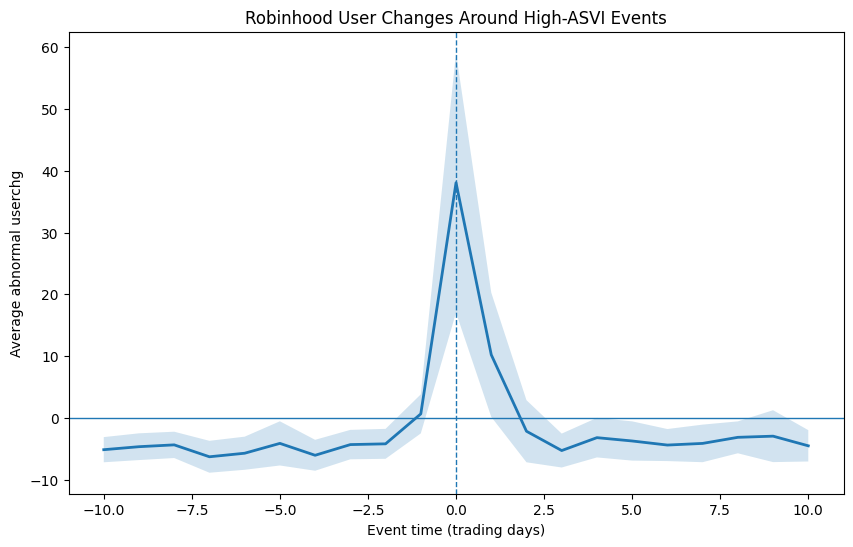

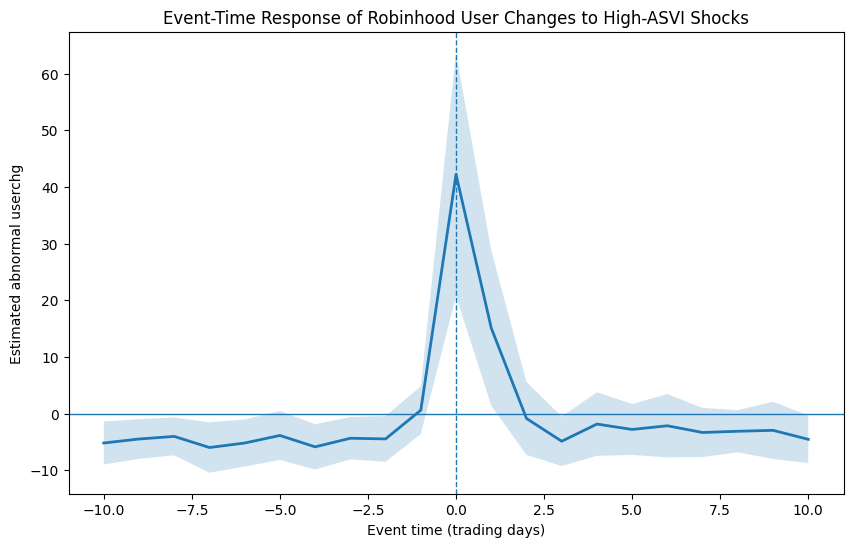

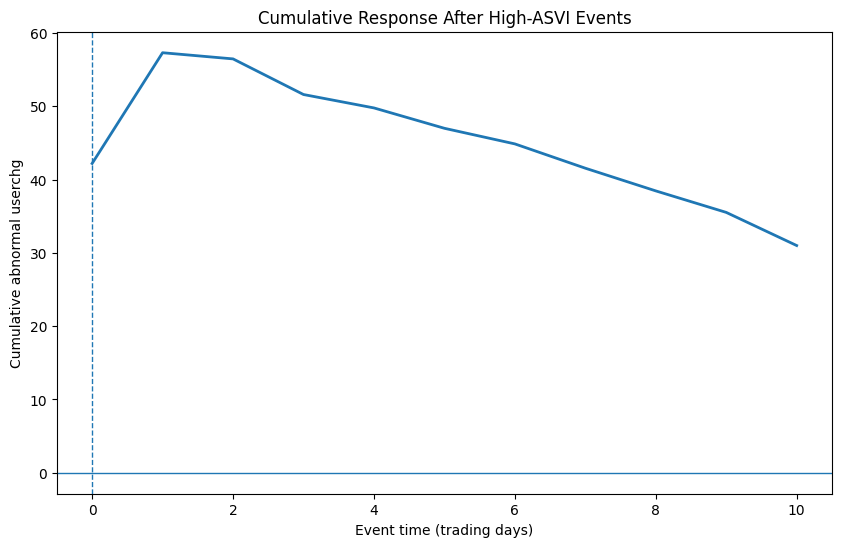

In [51]:
# ============================================================
# 1. PREPARE PANEL
# ============================================================

df = main.copy()

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)
df = df.dropna(subset=['ticker', 'date', 'userchg', 'intraday_userchg', 'svi']).copy()

# correct value for intraday_userchg
df['intraday_userchg'] *= -1

# build contemporaneous abnormal SVI
def make_ab_svi(s):
    mu = s.shift(1).rolling(window=20, min_periods=20).mean()
    ratio = s / mu
    ratio[(mu <= 0) | (~np.isfinite(ratio))] = np.nan
    return np.log1p(ratio)

df['asvi_t'] = df.groupby('ticker')['svi'].transform(make_ab_svi)

# keep stocks with enough data
stock_counts = df.groupby('ticker')['date'].transform('count')
df = df[stock_counts >= 60].copy()

# trading-time index within stock
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)
df['td_index'] = df.groupby('ticker').cumcount()

# ============================================================
# 2. DEFINE HIGH-ASVI EVENTS
# ============================================================

df['asvi_p99_stock'] = df.groupby('ticker')['asvi_t'].transform(
    lambda x: x.quantile(0.99)
)

df['event_candidate'] = (
    (df['asvi_t'] >= df['asvi_p99_stock']) &
    (df['asvi_p99_stock'] > 0) &
    (df['asvi_t'] > 0)
).astype(int)

df['event_onset'] = (
    (df['event_candidate'] == 1) &
    (df.groupby('ticker')['event_candidate'].shift(1).fillna(0) == 0)
).astype(int)

# ============================================================
# 3. ENFORCE NON-OVERLAP
# ============================================================

event_window = 10
min_gap = 2 * event_window + 1   # 21 trading days

def keep_non_overlapping_events(g, min_gap):
    g = g.sort_values('td_index').copy()
    event_positions = g.loc[g['event_onset'] == 1, 'td_index'].tolist()

    keep = []
    last_kept = -np.inf
    for pos in event_positions:
        if pos - last_kept >= min_gap:
            keep.append(pos)
            last_kept = pos

    g['event_keep'] = g['td_index'].isin(keep).astype(int)
    return g

df = df.groupby('ticker', group_keys=False).apply(
    keep_non_overlapping_events,
    min_gap=min_gap
)

# ============================================================
# 4. RESIDUALIZE USERCHG WITH STOCK AND DATE FE
# ============================================================

df_fe = df.set_index(['ticker', 'date']).sort_index()

y = df_fe['userchg']
X = pd.DataFrame({'const': 1.0}, index=df_fe.index)

fe_model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

fe_res = fe_model.fit()
df_fe['userchg_abn'] = fe_res.resids
df = df_fe.reset_index()

# ============================================================
# 5. BUILD EVENT-TIME PANEL
# ============================================================

window_list = []

for ticker, g in df.groupby('ticker'):
    g = g.sort_values('td_index').reset_index(drop=True)
    event_rows = g.index[g['event_keep'] == 1].tolist()

    for row_idx in event_rows:
        event_td = g.loc[row_idx, 'td_index']
        event_date = g.loc[row_idx, 'date']

        lower_td = event_td - event_window
        upper_td = event_td + event_window

        win = g[(g['td_index'] >= lower_td) & (g['td_index'] <= upper_td)].copy()
        win['event_time'] = win['td_index'] - event_td
        win['event_id'] = f"{ticker}_{event_date.strftime('%Y%m%d')}"
        win['event_ticker'] = ticker
        win['event_date'] = event_date

        window_list.append(
            win[['event_id', 'event_ticker', 'event_date', 'date',
                 'event_time', 'userchg', 'userchg_abn', 'asvi_t']]
        )

event_panel = pd.concat(window_list, ignore_index=True)

# keep only complete windows
complete_counts = event_panel.groupby('event_id')['event_time'].nunique()
complete_ids = complete_counts[complete_counts == (2 * event_window + 1)].index
event_panel_bal = event_panel[event_panel['event_id'].isin(complete_ids)].copy()

# ============================================================
# 6. EVENT-TIME AVERAGES
# ============================================================

avg_path = (
    event_panel_bal
    .groupby('event_time')
    .agg(
        avg_userchg=('userchg', 'mean'),
        avg_userchg_abn=('userchg_abn', 'mean'),
        sd_userchg_abn=('userchg_abn', 'std'),
        n_events=('event_id', 'nunique')
    )
    .reset_index()
    .sort_values('event_time')
)

avg_path['se_userchg_abn'] = avg_path['sd_userchg_abn'] / np.sqrt(avg_path['n_events'])
avg_path['ci_low'] = avg_path['avg_userchg_abn'] - 1.96 * avg_path['se_userchg_abn']
avg_path['ci_high'] = avg_path['avg_userchg_abn'] + 1.96 * avg_path['se_userchg_abn']

avg_path['cum_avg_userchg_abn'] = np.nan
mask = avg_path['event_time'] >= 0
avg_path.loc[mask, 'cum_avg_userchg_abn'] = avg_path.loc[mask, 'avg_userchg_abn'].cumsum()

print(avg_path)

# ============================================================
# 7. LOCAL-PROJECTION EVENT-STUDY ESTIMATES
#    beta_h = average abnormal userchg at horizon h after event onset
# ============================================================

# Align outcomes at horizon h back to event date t
lp_df = df.copy()

# event indicator on event date t
lp_df['event_keep'] = lp_df['event_keep'].astype(int)

# clustering variables
lp_df['ticker_clust'] = lp_df['ticker'].astype('category').cat.codes
lp_df['date_clust'] = lp_df['date'].astype('category').cat.codes

horizons = list(range(-event_window, event_window + 1))
lp_results = []

for h in horizons:
    temp = lp_df[['ticker', 'date', 'userchg_abn', 'event_keep',
                  'ticker_clust', 'date_clust']].copy()

    # outcome at t+h, aligned to row t
    temp['y_h'] = temp.groupby('ticker')['userchg_abn'].shift(-h)

    temp = temp.dropna(subset=['y_h', 'event_keep']).copy()

    X = sm.add_constant(temp[['event_keep']])
    y = temp['y_h']

    res = sm.OLS(y, X).fit(
        cov_type='cluster',
        cov_kwds={'groups': temp[['ticker_clust', 'date_clust']]}
    )

    beta = res.params['event_keep']
    se = res.bse['event_keep']

    lp_results.append({
        'event_time': h,
        'beta': beta,
        'se': se,
        'ci_low': beta - 1.96 * se,
        'ci_high': beta + 1.96 * se,
        'n_obs': len(temp)
    })

lp_results = pd.DataFrame(lp_results).sort_values('event_time').copy()
lp_results['cum_beta'] = np.nan

mask = lp_results['event_time'] >= 0
lp_results.loc[mask, 'cum_beta'] = lp_results.loc[mask, 'beta'].cumsum()

print(lp_results)

# ============================================================
# 8. PLOTS
# ============================================================

# Average abnormal userchg around event
plt.figure(figsize=(10, 6))
plt.plot(avg_path['event_time'], avg_path['avg_userchg_abn'], linewidth=2)
plt.fill_between(
    avg_path['event_time'],
    avg_path['ci_low'],
    avg_path['ci_high'],
    alpha=0.2
)
plt.axvline(0, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.xlabel('Event time (trading days)')
plt.ylabel('Average abnormal userchg')
plt.title('Robinhood User Changes Around High-ASVI Events')
plt.show()

# Local-projection estimates with clustered SEs
plt.figure(figsize=(10, 6))
plt.plot(lp_results['event_time'], lp_results['beta'], linewidth=2)
plt.fill_between(
    lp_results['event_time'],
    lp_results['ci_low'],
    lp_results['ci_high'],
    alpha=0.2
)
plt.axvline(0, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.xlabel('Event time (trading days)')
plt.ylabel('Estimated abnormal userchg')
plt.title('Event-Time Response of Robinhood User Changes to High-ASVI Shocks')
plt.show()

# Cumulative abnormal response
plt.figure(figsize=(10, 6))
cum_df = lp_results[lp_results['event_time'] >= 0].copy()
plt.plot(cum_df['event_time'], cum_df['cum_beta'], linewidth=2)
plt.axvline(0, linestyle='--', linewidth=1)
plt.axhline(0, linestyle='-', linewidth=1)
plt.xlabel('Event time (trading days)')
plt.ylabel('Cumulative abnormal userchg')
plt.title('Cumulative Response After High-ASVI Events')
plt.show()

A refined version of my experiment:

In [58]:
# ============================================================
# EVENT STUDY OF ROBINHOOD USER FLOWS AROUND HIGH-ATTENTION SHOCKS
# Refined descriptive design:
#   1. Event defined on lagged attention (asvi_{i,t-1})
#   2. Non-overlapping stock-specific events
#   3. FE residualization of user flows
#   4. Event-time averages
#   5. Local projections with controls and two-way clustered SEs
# ============================================================


# ------------------------------------------------------------
# 0. USER-SET PARAMETERS
# ------------------------------------------------------------
EVENT_WINDOW = 10                      # event window: [-10, +10]
MIN_STOCK_OBS = 60                     # minimum stock history
ASVI_LOOKBACK = 20                     # rolling mean lookback for ASVI
EVENT_QUANTILE = 0.99                  # stock-specific threshold for high attention
MIN_GAP = 2 * EVENT_WINDOW + 1         # non-overlap in trading days
USE_INTRADAY_USERCHG = False           # set True if you want intraday flow as outcome
PLOT_90CI = True                      # False = 95% CI; True = 90% CI

# ------------------------------------------------------------
# 1. LOAD AND PREPARE PANEL
# ------------------------------------------------------------
df = main.copy()

# Required columns
required_cols = ['ticker', 'date', 'svi', 'userchg']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

# Optional choice of outcome
outcome_col = 'intraday_userchg' if USE_INTRADAY_USERCHG else 'userchg'
if outcome_col not in df.columns:
    raise ValueError(f"Outcome column '{outcome_col}' not found.")

# Drop key missing values
base_drop = ['ticker', 'date', 'svi', outcome_col]
df = df.dropna(subset=base_drop).copy()

# If using the intraday measure and your convention requires sign correction:
if USE_INTRADAY_USERCHG:
    df['intraday_userchg'] = -1 * df['intraday_userchg']

# Keep stocks with enough observations
stock_counts = df.groupby('ticker')['date'].transform('count')
df = df.loc[stock_counts >= MIN_STOCK_OBS].copy()

# Trading-day index within stock
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)
df['td_index'] = df.groupby('ticker').cumcount()

# ------------------------------------------------------------
# 2. BUILD ATTENTION MEASURE
# ------------------------------------------------------------
# ASVI_{i,t} = log(1 + SVI_{i,t} / mean(SVI_{i,t-1},...,SVI_{i,t-20}))
def make_asvi(s, lookback=20):
    baseline = s.shift(1).rolling(window=lookback, min_periods=lookback).mean()
    ratio = s / baseline
    ratio[(baseline <= 0) | (~np.isfinite(ratio))] = np.nan
    return np.log1p(ratio)

df['asvi_t'] = df.groupby('ticker')['svi'].transform(lambda s: make_asvi(s, ASVI_LOOKBACK))

# Lagged ASVI for event definition
df['asvi_lag1'] = df.groupby('ticker')['asvi_t'].shift(1)

# ------------------------------------------------------------
# 3. BUILD CONTROL VARIABLES
# ------------------------------------------------------------
# 3A. Returns / abnormal returns
# Use 'aret' if already present, else use 'ret' if available, else skip return controls.
if 'aret' in df.columns:
    df['ret_ctrl'] = df['aret']
elif 'ret' in df.columns:
    df['ret_ctrl'] = df['ret']
else:
    df['ret_ctrl'] = np.nan

# Lagged returns
df['ret_lag1'] = df.groupby('ticker')['ret_ctrl'].shift(1)

# 3B. Abnormal turnover / abnormal volume control
# Preferred:
#   abturn_{i,t} = log(1 + vol_{i,t}) - mean_{k=1,...,20}[log(1 + vol_{i,t-k})]
# Fallback to missing if vol unavailable.
if 'vol' in df.columns:
    df['logvol'] = np.log1p(df['vol'])
    vol_ma = df.groupby('ticker')['logvol'].transform(
        lambda s: s.shift(1).rolling(window=20, min_periods=20).mean()
    )
    df['abturn'] = df['logvol'] - vol_ma
else:
    df['abturn'] = np.nan

df['abturn_lag1'] = df.groupby('ticker')['abturn'].shift(1)

# 3C. Lagged dependent variable
df['y_lag1'] = df.groupby('ticker')[outcome_col].shift(1)

# ------------------------------------------------------------
# 4. DEFINE HIGH-ATTENTION EVENTS ON LAGGED ASVI
# ------------------------------------------------------------
# Stock-specific threshold based on lagged ASVI
df['asvi_lag1_pq_stock'] = df.groupby('ticker')['asvi_lag1'].transform(
    lambda x: x.quantile(EVENT_QUANTILE)
)

# Event candidate: yesterday's attention is in the top 1% of this stock's history
df['event_candidate'] = (
    (df['asvi_lag1'] >= df['asvi_lag1_pq_stock']) &
    (df['asvi_lag1_pq_stock'] > 0) &
    (df['asvi_lag1'] > 0)
).astype(int)

# Event onset: first day of a run of event_candidate = 1
df['event_onset'] = (
    (df['event_candidate'] == 1) &
    (df.groupby('ticker')['event_candidate'].shift(1).fillna(0) == 0)
).astype(int)

# ------------------------------------------------------------
# 5. ENFORCE NON-OVERLAP
# ------------------------------------------------------------
def keep_non_overlapping_events(g, min_gap):
    g = g.sort_values('td_index').copy()
    event_positions = g.loc[g['event_onset'] == 1, 'td_index'].tolist()

    keep = []
    last_kept = -np.inf
    for pos in event_positions:
        if pos - last_kept >= min_gap:
            keep.append(pos)
            last_kept = pos

    g['event_keep'] = g['td_index'].isin(keep).astype(int)
    return g

df = df.groupby('ticker', group_keys=False).apply(
    keep_non_overlapping_events,
    min_gap=MIN_GAP
)

# ------------------------------------------------------------
# 6. RESIDUALIZE OUTCOME WITH STOCK AND DATE FE
# ------------------------------------------------------------
# y_{i,t} = alpha_i + delta_t + u_{i,t}
# Keep residual u_{i,t} as abnormal user flow.
df_fe = df.set_index(['ticker', 'date']).sort_index()

y = df_fe[outcome_col]
X = pd.DataFrame({'const': 1.0}, index=df_fe.index)

fe_model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

fe_res = fe_model.fit()
df_fe['y_abn'] = fe_res.resids
df = df_fe.reset_index()

# Lagged abnormal flow control
df['y_abn_lag1'] = df.groupby('ticker')['y_abn'].shift(1)

# ------------------------------------------------------------
# 7. BUILD BALANCED EVENT-TIME PANEL
# ------------------------------------------------------------
window_list = []

for ticker, g in df.groupby('ticker'):
    g = g.sort_values('td_index').reset_index(drop=True)
    event_rows = g.index[g['event_keep'] == 1].tolist()

    for row_idx in event_rows:
        event_td = g.loc[row_idx, 'td_index']
        event_date = g.loc[row_idx, 'date']

        lower_td = event_td - EVENT_WINDOW
        upper_td = event_td + EVENT_WINDOW

        win = g[(g['td_index'] >= lower_td) & (g['td_index'] <= upper_td)].copy()
        win['event_time'] = win['td_index'] - event_td
        win['event_id'] = f"{ticker}_{event_date.strftime('%Y%m%d')}"
        win['event_ticker'] = ticker
        win['event_date'] = event_date

        keep_cols = [
            'event_id', 'event_ticker', 'event_date', 'date', 'event_time',
            outcome_col, 'y_abn', 'asvi_t', 'asvi_lag1',
            'ret_lag1', 'abturn_lag1', 'y_abn_lag1'
        ]
        keep_cols = [c for c in keep_cols if c in win.columns]
        window_list.append(win[keep_cols])

if len(window_list) == 0:
    raise ValueError("No event windows were constructed. Check event definition.")

event_panel = pd.concat(window_list, ignore_index=True)

# Keep only complete windows
complete_counts = event_panel.groupby('event_id')['event_time'].nunique()
complete_ids = complete_counts[complete_counts == (2 * EVENT_WINDOW + 1)].index
event_panel_bal = event_panel[event_panel['event_id'].isin(complete_ids)].copy()

if event_panel_bal.empty:
    raise ValueError("No balanced event windows remain after requiring completeness.")

# ------------------------------------------------------------
# 8. EVENT-TIME AVERAGES
# ------------------------------------------------------------
avg_path = (
    event_panel_bal
    .groupby('event_time')
    .agg(
        avg_y=('y_abn', 'mean'),
        sd_y=('y_abn', 'std'),
        n_events=('event_id', 'nunique'),
        avg_asvi_lag1=('asvi_lag1', 'mean')
    )
    .reset_index()
    .sort_values('event_time')
)

avg_path['se_y'] = avg_path['sd_y'] / np.sqrt(avg_path['n_events'])

crit = 1.645 if PLOT_90CI else 1.96
avg_path['ci_low'] = avg_path['avg_y'] - crit * avg_path['se_y']
avg_path['ci_high'] = avg_path['avg_y'] + crit * avg_path['se_y']

avg_path['cum_avg_y'] = np.nan
mask_post = avg_path['event_time'] >= 0
avg_path.loc[mask_post, 'cum_avg_y'] = avg_path.loc[mask_post, 'avg_y'].cumsum()

print("\n================ EVENT-TIME AVERAGES ================\n")
print(avg_path)

# ------------------------------------------------------------
# 9. LOCAL PROJECTIONS WITH CONTROLS
# ------------------------------------------------------------
# For each horizon h:
#   y_abn_{i,t+h} = alpha_h + beta_h * Event_{i,t}
#                 + Gamma_h' X_{i,t-1} + e_{i,t+h}
#
# where X_{i,t-1} includes lagged abnormal flow, lagged return,
# and lagged abnormal turnover whenever available.

lp_df = df.copy()
lp_df['event_keep'] = lp_df['event_keep'].astype(int)

# Two-way clustering identifiers
lp_df['ticker_clust'] = lp_df['ticker'].astype('category').cat.codes
lp_df['date_clust'] = lp_df['date'].astype('category').cat.codes

control_candidates = ['y_abn_lag1', 'ret_lag1', 'abturn_lag1']
controls = [c for c in control_candidates if c in lp_df.columns]

horizons = list(range(-EVENT_WINDOW, EVENT_WINDOW + 1))
lp_results = []

for h in horizons:
    temp = lp_df[['ticker', 'date', 'y_abn', 'event_keep',
                  'ticker_clust', 'date_clust'] + controls].copy()

    # Align outcome y_{t+h} to row t
    temp['y_h'] = temp.groupby('ticker')['y_abn'].shift(-h)

    # Drop rows with missing outcome or regressors
    req = ['y_h', 'event_keep'] + controls
    temp = temp.dropna(subset=req).copy()

    Xcols = ['event_keep'] + controls
    X = sm.add_constant(temp[Xcols])
    y = temp['y_h']

    res = sm.OLS(y, X).fit(
        cov_type='cluster',
        cov_kwds={'groups': temp[['ticker_clust', 'date_clust']]}
    )

    beta = res.params['event_keep']
    se = res.bse['event_keep']

    lp_results.append({
        'event_time': h,
        'beta': beta,
        'se': se,
        'tstat': beta / se if se != 0 else np.nan,
        'pval': res.pvalues['event_keep'],
        'ci_low': beta - crit * se,
        'ci_high': beta + crit * se,
        'n_obs': len(temp)
    })

lp_results = pd.DataFrame(lp_results).sort_values('event_time').copy()
lp_results['cum_beta'] = np.nan
mask_post = lp_results['event_time'] >= 0
lp_results.loc[mask_post, 'cum_beta'] = lp_results.loc[mask_post, 'beta'].cumsum()

print("\n================ LOCAL PROJECTION RESULTS ================\n")
print(lp_results)

# ------------------------------------------------------------
# 10. OPTIONAL PRE-TREND JOINT TEST
# ------------------------------------------------------------
# Test whether all pre-event betas for h in {-10,...,-2} are jointly zero.
# Here we exclude h = -1 because the event is defined using attention on t-1,
# so h = -1 is mechanically adjacent to the trigger day.
pretrend_df = lp_results[(lp_results['event_time'] >= -EVENT_WINDOW) &
                         (lp_results['event_time'] <= -2)].copy()

print("\n================ PRE-TREND CHECK ================\n")
print(pretrend_df[['event_time', 'beta', 'se', 'tstat', 'pval']])



# ------------------------------------------------------------
# 12. SAVE OUTPUTS (OPTIONAL)
# ------------------------------------------------------------
# avg_path.to_csv("event_time_averages_refined.csv", index=False)
# lp_results.to_csv("local_projection_results_refined.csv", index=False)
# event_panel_bal.to_csv("event_panel_balanced_refined.csv", index=False)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_80032/345981881.py:144: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('ticker', group_keys=False).apply(
/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_80032/345981881.py:167: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  fe_res = fe_model.fit()



================ EVENT-TIME AVERAGES ================

    event_time      avg_y        sd_y  n_events  avg_asvi_lag1       se_y  \
0          -10  -4.675440   95.988393      7542       0.195350   1.105288   
1           -9  -4.461479   93.953144      7542       0.181311   1.081853   
2           -8  -6.416456  113.869071      7542       0.179933   1.311181   
3           -7  -5.766098  118.732753      7542       0.191073   1.367185   
4           -6  -4.240657  158.407201      7542       0.195242   1.824029   
5           -5  -6.160054  110.397782      7542       0.188221   1.271209   
6           -4  -4.306411  105.583179      7542       0.199088   1.215770   
7           -3  -4.142661  107.441101      7542       0.183667   1.237164   
8           -2  -0.009149  126.918602      7542       0.188903   1.461443   
9           -1  36.596264  926.181550      7542       0.178275  10.664804   
10           0   9.505961  441.538714      7542       3.017138   5.084234   
11           1  -1.9

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1


================ LOCAL PROJECTION RESULTS ================

    event_time          beta            se     tstat      pval        ci_low  \
0          -10 -1.612040e+01  4.135097e+00 -3.898435  0.000097 -2.292264e+01   
1           -9 -1.729920e+01  4.379782e+00 -3.949785  0.000078 -2.450394e+01   
2           -8 -2.009774e+01  4.829240e+00 -4.161677  0.000032 -2.804184e+01   
3           -7 -1.991744e+01  4.757561e+00 -4.186481  0.000028 -2.774363e+01   
4           -6 -1.960087e+01  4.912933e+00 -3.989647  0.000066 -2.768264e+01   
5           -5 -2.106764e+01  4.864674e+00 -4.330740  0.000015 -2.907002e+01   
6           -4 -1.938017e+01  5.043376e+00 -3.842698  0.000122 -2.767652e+01   
7           -3 -2.190082e+01  5.416187e+00 -4.043587  0.000053 -3.081045e+01   
8           -2 -2.467355e+01  6.224169e+00 -3.964152  0.000074 -3.491231e+01   
9           -1 -1.687539e-13  1.171154e-13 -1.440919  0.149607 -3.614088e-13   
10           0 -1.065768e+01  4.769905e+00 -2.234360  0.025

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


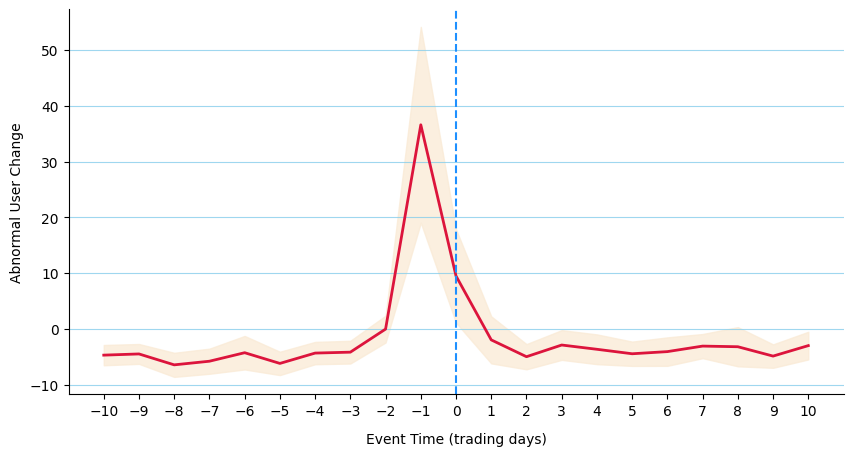

In [101]:
# ------------------------------------------------------------
# 11. PLOT
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_path['event_time'], avg_path['avg_y'], linewidth=2, color='crimson')
ax.fill_between(
    avg_path['event_time'],
    avg_path['ci_low'],
    avg_path['ci_high'],
    alpha=0.8,
    color='antiquewhite'
)
ax.axvline(0, linestyle='--', linewidth=1.5, color='dodgerblue', zorder=2)
ax.set_xlabel('Event Time (trading days)', labelpad=10)
ax.set_xticks(range(-EVENT_WINDOW, EVENT_WINDOW + 1, 1))
ax.set_ylabel(f'Abnormal User Change')
# ax.set_title('Panel A: Average Abnormal Robinhood User Change Around Lagged High-ASVI Events', fontsize=12, family='Times New Roman', pad=22)
ax.grid(alpha=0.8, color='skyblue', axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("../../../figures/event_study_I.pdf", bbox_inches='tight')
plt.show()

#### Comments

These figures support one clear and fairly strong conclusion: high contemporaneous ASVI episodes are associated with a sharp, short-lived surge in abnormal Robinhood user inflows on the event day, followed by rapid normalization and then mild reversal over the subsequent trading days. That pattern is visible in both the simple event-time averages and the local-projection estimates, which is reassuring. It is also economically consistent with the attention-induced trading mechanism in which retail attention generates temporary buying pressure rather than persistent demand. Da, Engelberg, and Gao argue that abnormal search attention should produce short-run price pressure and later reversal, and Barber et al. document that intense Robinhood buying around attention-driven episodes forecasts negative subsequent returns.  ￼

The cleanest reading of these first two panels is this. Before the event, abnormal *userchg* is slightly negative and fairly stable. At event time 0, it jumps very sharply, to roughly 40 abnormal users. At event time +1, it remains positive but much smaller. By about +2, the effect is already close to zero, and from about +3 onward the path is mildly negative. That is not a gradual buildup of retail participation. It is a burst-and-fade pattern. The fact that the local-projection figure looks nearly identical to the raw event-time average strengthens the descriptive conclusion, because it suggests the shape is not an artifact of the simple averaging procedure alone.

The cumulative plot adds an important nuance. The post-event cumulative abnormal *userchg* remains positive even ten trading days later, although it decays materially from its initial peak. So the right statement is not that the event fully reverses in holdings space over the next ten days. Rather, there is a large immediate inflow, followed by partial unwind. In other words, high-ASVI shocks appear to attract Robinhood users quickly, but the induced increase in holders is not fully permanent and begins to erode soon after the event. That distinction matters. In returns, the literature emphasizes temporary price pressure and reversal. In holdings, one should expect weaker and slower reversal because some investors who buy do not immediately exit. ￼

So the most defensible substantive conclusion is this: contemporaneous spikes in Google-search-based attention coincide with substantial **same-day** abnormal growth in Robinhood ownership, and this attention-driven demand effect is highly transitory in flow terms. The event-day effect is large; the incremental effect after day +1 is small to negative. This is exactly the type of dynamic one would expect if attention shocks mobilize retail buying quickly and then fade. It is also aligned with later evidence that retail attention is associated with contemporaneous buying pressure and subsequent correction.  ￼

What we should not claim from these figures is causality. This is still an event study around endogenous attention realizations, not around exogenous shocks. High ASVI may reflect the market reacting to news, price moves, social media, or platform salience. The event study establishes a tight dynamic association, not an exogenous treatment effect. That caveat is important if I want this to read like top-field empirical work.

There is a second caution. My event date is defined using contemporaneous $\text{asvi}_t$, which is built from the same day’s SVI relative to the trailing 20-day mean. That improves the timing relative to my earlier lagged-ASVI exercise, but it also means event time 0 is the day on which attention is already abnormally high. **So the spike at day 0 is best interpreted as a contemporaneous response, not as a predictive effect**. This distinction reconciles my earlier panel regressions: lagged ASVI could turn weak or negative once lagged user changes are included, while contemporaneous high-ASVI events can still be associated with a strong same-day inflow. The dynamic story is then coherent: attention shocks and Robinhood inflows occur together on impact, and most of the action is absorbed immediately rather than with a long delay.

Methodologically, the figures are credible enough to report as an event-time characterization, but I would still tighten three things before treating them as final. First, the confidence bands in the first panel are constructed from simple cross-event dispersion, whereas the second panel uses two-way clustered inference. For the paper, the local-projection figure is the more defensible inferential object. Second, because ASVI is defined as an extreme within-stock percentile event, I should report the number of retained events explicitly in the figure note or text. Third, I would show robustness to an alternative event threshold, such as the within-stock top 5% instead of top 1%. If the burst-and-fade shape survives, the interpretation becomes much stronger.

#### CORE MESSAGE

High ASVI is strongly associated with same-day abnormal Robinhood user inflows, but this event-study design does not establish that the Google searches themselves cause the inflows. More plausibly, both are jointly driven by some underlying attention trigger, such as news, extreme price moves, social media discussion, or platform salience. This is exactly why the attention literature distinguishes between direct measures of attention and the underlying sources of attention. Da et al. argue that search data are a more direct measure of investor attention than news or returns, but even then, the search itself is still a manifestation of attention, not necessarily its ultimate origin.

For an investor to search for a stock by name or ticker, the stock has usually already entered that investor’s consideration set somehow. That "somehow" may be a news item, a large return, Reddit, the Robinhood Top Movers list, or word of mouth. Barber and Odean’s core idea is exactly that attention first narrows the choice set, and only then do investors decide whether to buy.  Robinhood-specific features can also create that initial salience: Barber et al. show that the app’s Top Movers display affects Robinhood user behavior, which means the platform itself can be a source of the attention shock that later shows up in Google searches and trading.

## 5. External Validity

To assess whether the results are specific to Robinhood-based holdings changes or instead generalize to broader retail trading activity, I re-estimate the baseline specification using TAQ-based retail net buys as the dependent variable. Because the TAQ and Robintrack measures capture distinct but related dimensions of retail participation, similar coefficient patterns across the two specifications would support the external validity of the Robinhood-based findings.

In [22]:
reg5 = df_reg_1.copy().dropna(subset=['net_buys', 'top_20', 'ab_vol_lag1',
                                      'net_buys_lag1', 'asvi', 'num_news_lag1',
                                      'num_news_relevant_lag1',
                                      'ess_lag1', 'css_lag1', 'anl_chg_lag1'])

# make sure date is datetime
reg5['date'] = pd.to_datetime(reg5['date'])

# convert clusters to integer codes
reg5['ticker_clust'] = reg5['ticker'].astype('category').cat.codes
reg5['date_clust'] = reg5['date'].astype('category').cat.codes

X5 = sm.add_constant(reg5[['top_20', 'ab_vol_lag1', 'net_buys_lag1', 'asvi', 'num_news_lag1',
                           'num_news_relevant_lag1', 'ess_lag1', 'css_lag1', 'anl_chg_lag1' ]])
y5 = reg5['net_buys']

results5 = OLS(y5, X5).fit(
    cov_type='clustered',
    clusters=reg5[['ticker_clust', 'date_clust']]
)

print(results5.summary)

                            OLS Estimation Summary                            
Dep. Variable:               net_buys   R-squared:                      0.4807
Estimator:                        OLS   Adj. R-squared:                 0.4807
No. Observations:              981655   F-statistic:                    602.02
Date:                Fri, Apr 03 2026   P-value (F-stat)                0.0000
Time:                        13:55:50   Distribution:                  chi2(9)
Cov. Estimator:             clustered                                         
                                                                              
                                   Parameter Estimates                                    
                        Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------
const                      20.341     3.0973     6.5675     0.0000      14.271      26.412
top_

In [23]:
reg5_a = df_reg_1.copy().dropna(subset=['net_buys', 'top_20', 'ab_vol_lag1',
                                      'net_buys_lag1', 'asvi', 'num_news_lag1',
                                      'num_news_relevant_lag1',
                                      'ess_lag1', 'css_lag1', 'anl_chg_lag1'])

# make sure date is datetime
reg5_a['date'] = pd.to_datetime(reg5_a['date'])

# set panel index: entity = ticker, time = date
reg5_a = reg5_a.set_index(['ticker', 'date']).sort_index()

# dependent variable
y5a = reg5_a['net_buys']

# regressors: do NOT add a constant when using both entity and time fixed effects
X5a = reg5_a[[
    'top_20', 'ab_vol_lag1', 'net_buys_lag1', 'asvi', 'num_news_lag1',
    'num_news_relevant_lag1', 'ess_lag1', 'css_lag1', 'anl_chg_lag1'
]]

# estimate with stock and date fixed effects
model5a = PanelOLS(
    y5a,
    X5a,
    entity_effects=True,   # stock fixed effects
    time_effects=True      # date fixed effects
)

results5a = model5a.fit(
    cov_type='clustered',
    cluster_entity=True,   # cluster by stock
    cluster_time=True      # cluster by date
)
print(results5a.summary)

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_80032/1731716927.py:29: MemoryWarning: Using low-memory algorithm to estimate two-way model. Explicitly set low_memory=True to silence this message.  Set low_memory=False to use the standard algorithm that creates dummy variables for the smaller of the number of entities or number of time periods.
  results5a = model5a.fit(


                          PanelOLS Estimation Summary                           
Dep. Variable:               net_buys   R-squared:                        0.4166
Estimator:                   PanelOLS   R-squared (Between):              0.8637
No. Observations:              981655   R-squared (Within):               0.4209
Date:                Fri, Apr 03 2026   R-squared (Overall):              0.4779
Time:                        13:55:54   Log-likelihood                -7.081e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                   7.768e+04
Entities:                        1957   P-value                           0.0000
Avg Obs:                       501.61   Distribution:                F(9,979127)
Min Obs:                       3.0000                                           
Max Obs:                       563.00   F-statistic (robust):             30.486
                            